"""  
Проект: Поиск аномалий в банковских транзакциях (Credit Card Fraud Detection)  
Автор: Кретов Александр Алексеевич  
Дата: 2026-05-12  
Описание: Используем unsupervised методы для обнаружения мошеннических транзакций.  
"""

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.neighbors import LocalOutlierFactor
import umap

c:\Users\Admin\miniconda3\envs\smog\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Загрузка данных

In [4]:
print("="*60)
print("ЗАГРУЗКА ДАННЫХ")
print("="*60)
DATA_PATH = "creditcard.csv"
  # Убедитесь, что файл находится в текущей папке
try:
    df = pd.read_csv(DATA_PATH)
    print(f"Датасет загружен. Размер: {df.shape[0]} строк, {df.shape[1]} столбцов.")
except FileNotFoundError:
    print("Ошибка: файл creditcard.csv не найден. Скачайте его с Kaggle: https://www.kaggle.com/mlg-ulb/creditcardfraud")
    raise

ЗАГРУЗКА ДАННЫХ
Датасет загружен. Размер: 284807 строк, 31 столбцов.


In [5]:
# Посмотрим на первые строки и основную информацию
print("\nПервые 5 записей:")
display(df.head())
print("\nТипы данных и пропуски:")
display(df.info())
print("\nОписательная статистика:")
display(df.describe())


Первые 5 записей:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Типы данных и пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null

None


Описательная статистика:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


# 2. Базовый EDA

In [12]:
# Проверка пропусков
print("\nПропущенные значения:")
print(df.isnull().sum().sum(), "пропусков всего")


Пропущенные значения:
0 пропусков всего


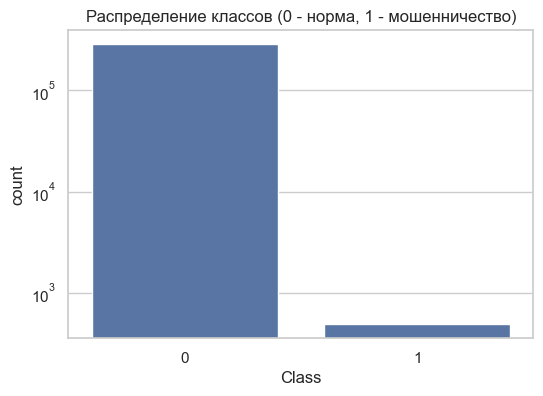


Количество нормальных транзакций: 284315
Количество мошеннических транзакций: 492
Доля аномалий (contamination): 0.001727 (0.1727%)


In [13]:
# Распределение целевой переменной Class
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Распределение классов (0 - норма, 1 - мошенничество)')
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.yscale('log')
plt.show()
fraud_count = df['Class'].sum()
normal_count = len(df) - fraud_count
contamination = fraud_count / len(df)
print(f"\nКоличество нормальных транзакций: {normal_count}")
print(f"Количество мошеннических транзакций: {fraud_count}")
print(f"Доля аномалий (contamination): {contamination:.6f} ({contamination*100:.4f}%)")


Построение гистограмм всех признаков...


Гистограммы: 100%|██████████| 30/30 [00:00<00:00, 40.60it/s]


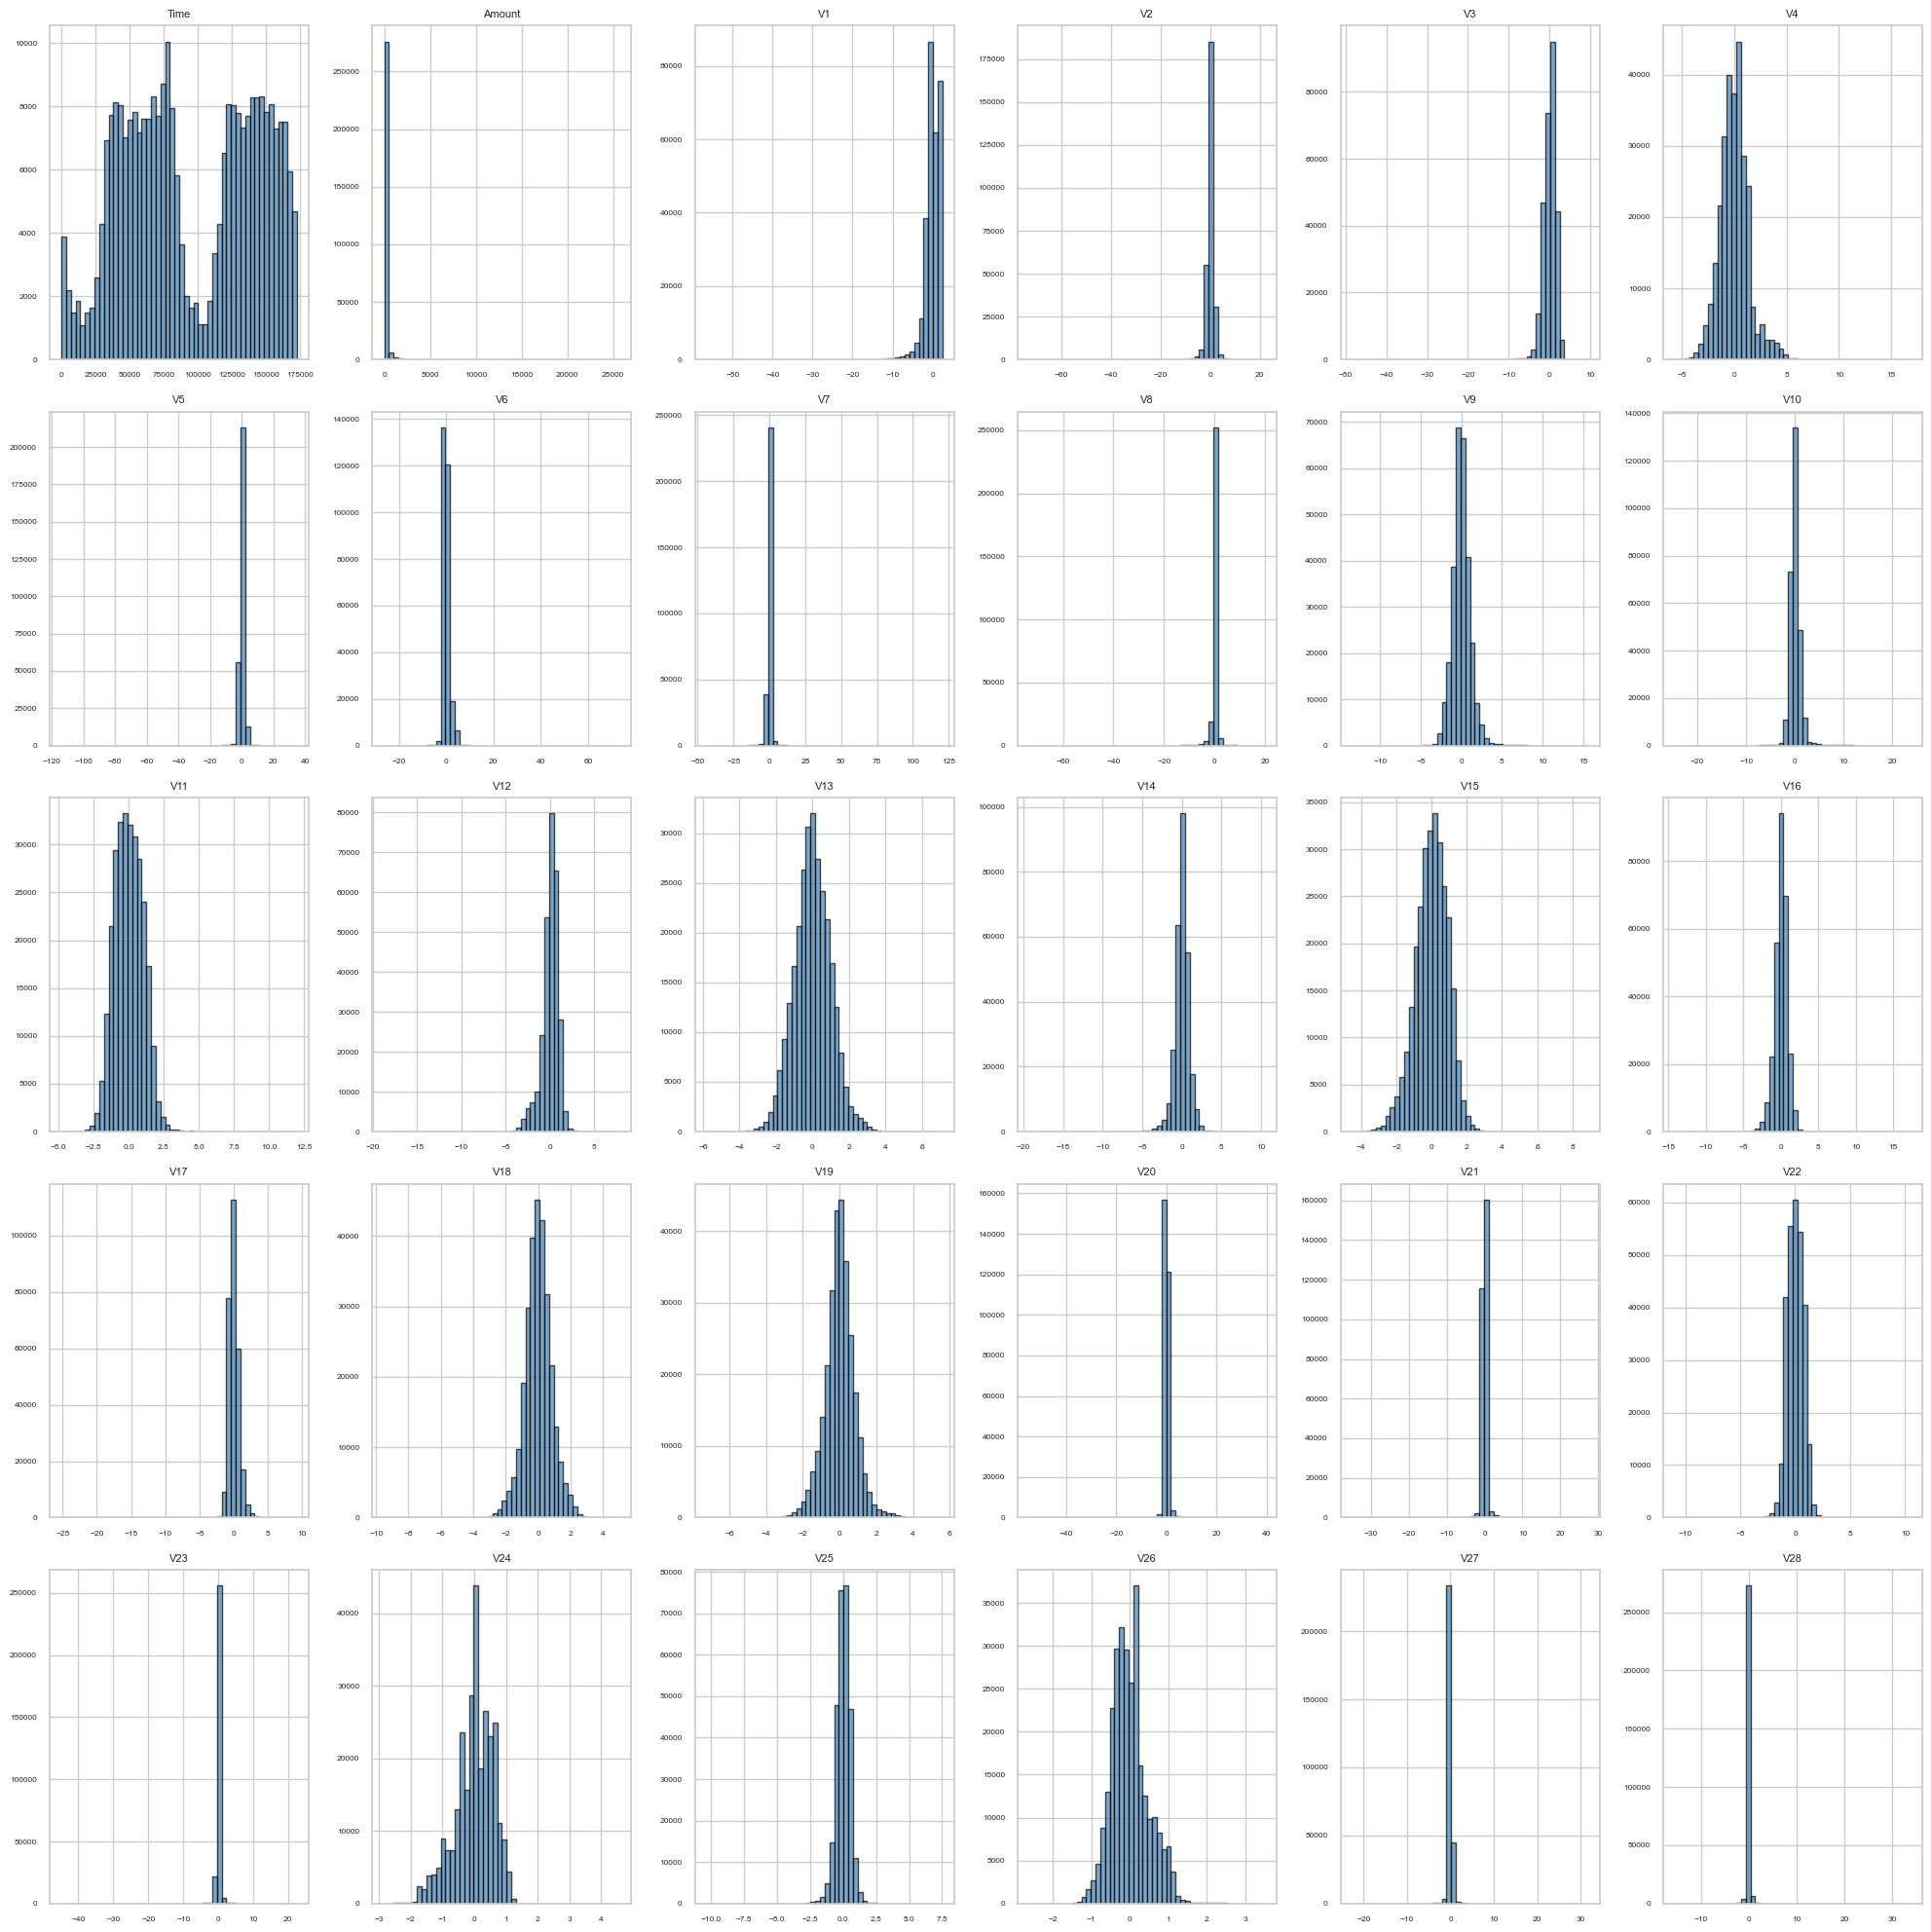

In [14]:
# Гистограммы для признаков V1..V28, Time, Amount
print("\nПостроение гистограмм всех признаков...")
features_to_plot = ['Time', 'Amount'] + [f'V{i}' for i in range(1, 29)]
n_cols = 6
n_rows = int(np.ceil(len(features_to_plot) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()
for i, feat in enumerate(tqdm(features_to_plot, desc="Гистограммы")):
    df[feat].hist(bins=50, ax=axes[i], color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(feat, fontsize=8)
    axes[i].tick_params(labelsize=6)
# Убираем пустые подграфики
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('histograms_all_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Описательные статистики ключевых признаков (первые 5 V-компонент + Amount + Time)
print("\nОписательные статистики выбранных признаков (округлены до 3 знаков):")
display(df[['Time', 'Amount', 'V1', 'V2', 'V3', 'V4', 'V5']].describe().round(3))


Описательные статистики выбранных признаков (округлены до 3 знаков):


,Time,Amount,V1,V2,V3,V4,V5
count,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000
mean,94813.860,88.350,0.000,0.000,-0.000,0.000,0.000
std,47488.146,250.120,1.959,1.651,1.516,1.416,1.380
min,0.000,0.000,-56.408,-72.716,-48.326,-5.683,-113.743
25%,54201.500,5.600,-0.920,-0.599,-0.890,-0.849,-0.692
50%,84692.000,22.000,0.018,0.065,0.180,-0.020,-0.054
75%,139320.500,77.165,1.316,0.804,1.027,0.743,0.612
max,172792.000,25691.160,2.455,22.058,9.383,16.875,34.802


In [16]:
# Вывод сводной таблицы EDA
eda_summary = pd.DataFrame({
    'Параметр': ['Общее число записей', 'Число признаков', 'Пропуски', 'Доля класса 1 (аномалии)'],
    'Значение': [len(df), df.shape[1]-1, df.isnull().sum().sum(), f"{contamination:.6f}"]
})
print("\n--- Сводная таблица EDA ---")
print(eda_summary.to_string(index=False))
eda_summary.to_csv('eda_summary.csv', index=False)


--- Сводная таблица EDA ---
                Параметр Значение
     Общее число записей   284807
         Число признаков       30
                Пропуски        0
Доля класса 1 (аномалии) 0.001727


## Основные выводы по распределениям  

*Датасет — типичный пример сильно несбалансированной задачи.*

1. Целевая переменная  
Сильнейший дисбаланс классов (~1:578). Стандартные метрики (accuracy) непригодны — нужны Precision/Recall, F1, PR-AUC, ROC-AUC.  
1. Признак Time  
Бимодальное распределение с двумя «провалами» — отражает суточный цикл активности (примерно 2 дня данных, с ночными снижениями).  
Может использоваться как фича «час суток» или «день».  
1. Признак Amount  
Сильно скошен вправо: медиана = 22, среднее = 88.35, max = 25 691.  
Большая часть транзакций — мелкие суммы.  
Требует логарифмирования или робастного масштабирования (RobustScaler/StandardScaler).  
1. PCA-признаки V1–V28  
Центрированы вокруг 0 (среднее ≈ 0), стандартизированы по построению PCA.  
Условно «нормально-подобные» формы: V11, V12, V13, V14, V15, V18, V19, V24, V26 — близки к нормальному.  
Сильно лептокуртические (узкий пик + тяжёлые хвосты): V8, V20, V21, V23, V27, V28 — высокий эксцесс, экстремальные выбросы (например, V5 от −113 до +34, V7 от −43 до +120).  
Различия дисперсий: V1–V5 имеют наибольший разброс (PCA-компоненты с большой долей объяснённой дисперсии).  
В признаках с тяжёлыми хвостами (V14, V17, V10, V12) обычно и сосредоточена «фрод-сигнатура».  


# 3. Подготовка данных

In [11]:
# Отделяем признаки и метки
X = df.drop('Class', axis=1)
y_true = df['Class']

# Масштабирование (важно для методов, чувствительных к расстоянию)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Данные отмасштабированы (StandardScaler).")


Данные отмасштабированы (StandardScaler).


Для вероятностного метода EllipticEnvelope оставим Amount и Time как есть,  
но будем использовать все признаки после масштабирования, т.к. PCA-компоненты уже центрированы.  
В целом все методы будут работать с X_scaled.

# 4. Модели поиска аномалий

In [17]:
models = {}
results = {}

# Параметр загрязнения берем из экспертной оценки (доля класса 1)
contamination_value = contamination
print(f"Используемый уровень загрязнения (contamination): {contamination_value:.6f}")

Используемый уровень загрязнения (contamination): 0.001727


In [18]:
# 4.1 Elliptic Envelope (вероятностный метод, предполагает гауссово распределение)
print("\n1. Elliptic Envelope (Robust covariance)")
start = time.time()
elle = EllipticEnvelope(contamination=contamination_value, random_state=42)
elle.fit(X_scaled)
y_pred_elle = elle.predict(X_scaled)
# predict возвращает 1 для inliers, -1 для outliers. Приведем к 0/1, где 1 - аномалия
y_pred_elle_bin = np.where(y_pred_elle == -1, 1, 0)
models['EllipticEnvelope'] = y_pred_elle_bin
print(f"Время обучения: {time.time()-start:.2f} сек")


1. Elliptic Envelope (Robust covariance)
Время обучения: 27.36 сек


In [19]:
# 4.2 Isolation Forest
print("\n2. Isolation Forest")
start = time.time()
iso = IsolationForest(contamination=contamination_value, random_state=42, n_jobs=-1)
iso.fit(X_scaled)
y_pred_iso = iso.predict(X_scaled)
y_pred_iso_bin = np.where(y_pred_iso == -1, 1, 0)
models['IsolationForest'] = y_pred_iso_bin
print(f"Время обучения: {time.time()-start:.2f} сек")


2. Isolation Forest
Время обучения: 2.19 сек


In [20]:
# 4.3 One-Class SVM (чувствителен к масштабу, используем подвыборку для скорости)
print("\n3. One-Class SVM (обучается на подвыборке 20% из-за высокой вычислительной сложности)")
# Для ускорения обучим на случайных 20% данных (но предсказания сделаем на всех)
sample_size = int(0.2 * len(X_scaled))
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_idx]
start = time.time()
ocsvm = OneClassSVM(nu=contamination_value, kernel='rbf', gamma='scale')
ocsvm.fit(X_sample)
# Предсказание на всех данных (может занять время)
y_pred_ocsvm = ocsvm.predict(X_scaled)
y_pred_ocsvm_bin = np.where(y_pred_ocsvm == -1, 1, 0)
models['OneClassSVM'] = y_pred_ocsvm_bin
print(f"Время обучения + предсказания: {time.time()-start:.2f} сек")


3. One-Class SVM (обучается на подвыборке 20% из-за высокой вычислительной сложности)
Время обучения + предсказания: 19.06 сек


In [21]:
# 4.4 Local Outlier Factor (плотностный метод)
print("\n4. Local Outlier Factor")
start = time.time()
lof = LocalOutlierFactor(contamination=contamination_value, n_jobs=-1)
y_pred_lof = lof.fit_predict(X_scaled)
y_pred_lof_bin = np.where(y_pred_lof == -1, 1, 0)
models['LocalOutlierFactor'] = y_pred_lof_bin
print(f"Время: {time.time()-start:.2f} сек")


4. Local Outlier Factor
Время: 27.84 сек


# 5. Оценка качества моделей

In [29]:
metrics_table = []
for name, y_pred in tqdm(models.items(), desc="Расчёт метрик"):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    # Извлекаем метрики для класса 1 (аномалии) и общую точность
    prec_1 = report['1']['precision']
    rec_1 = report['1']['recall']
    f1_1 = report['1']['f1-score']
    prec_0 = report['0']['precision']
    rec_0 = report['0']['recall']
    f1_0 = report['0']['f1-score']
    accuracy = report['accuracy']
    # Доля предсказанных аномалий
    pred_anomaly_frac = y_pred.sum() / len(y_pred)
    metrics_table.append([name, accuracy, prec_0, rec_0, f1_0, prec_1, rec_1, f1_1, pred_anomaly_frac])
    
    # Вывод подробного отчёта для каждой модели
    print(f"\n--- {name} ---")
    print("Confusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Fraud'], zero_division=0))

metrics_df = pd.DataFrame(metrics_table, columns=[
    'Model', 'Accuracy', 'Precision (0)', 'Recall (0)', 'F1 (0)',
    'Precision (1)', 'Recall (1)', 'F1 (1)', 'Predicted Anomaly Fraction'
])
print("\n--- Сводная таблица метрик ---")
display(metrics_df.round(4))
metrics_df.to_csv('model_metrics.csv', index=False)

Расчёт метрик:  25%|██▌       | 1/4 [00:00<00:00,  6.54it/s]


--- EllipticEnvelope ---
Confusion Matrix:
[[283832    483]
 [   483      9]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    284315
       Fraud       0.02      0.02      0.02       492

    accuracy                           1.00    284807
   macro avg       0.51      0.51      0.51    284807
weighted avg       1.00      1.00      1.00    284807


--- IsolationForest ---
Confusion Matrix:
[[283949    366]
 [   366    126]]

Classification Report:


Расчёт метрик:  75%|███████▌  | 3/4 [00:00<00:00,  6.63it/s]

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    284315
       Fraud       0.26      0.26      0.26       492

    accuracy                           1.00    284807
   macro avg       0.63      0.63      0.63    284807
weighted avg       1.00      1.00      1.00    284807


--- OneClassSVM ---
Confusion Matrix:
[[279466   4849]
 [   175    317]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99    284315
       Fraud       0.06      0.64      0.11       492

    accuracy                           0.98    284807
   macro avg       0.53      0.81      0.55    284807
weighted avg       1.00      0.98      0.99    284807



Расчёт метрик: 100%|██████████| 4/4 [00:00<00:00,  6.68it/s]


--- LocalOutlierFactor ---
Confusion Matrix:
[[283823    492]
 [   492      0]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    284315
       Fraud       0.00      0.00      0.00       492

    accuracy                           1.00    284807
   macro avg       0.50      0.50      0.50    284807
weighted avg       1.00      1.00      1.00    284807


--- Сводная таблица метрик ---


,Model,Accuracy,Precision (0),Recall (0),F1 (0),Precision (1),Recall (1),F1 (1),Predicted Anomaly Fraction
0,EllipticEnvelope,0.9966,0.9983,0.9983,0.9983,0.0183,0.0183,0.0183,0.0017
1,IsolationForest,0.9974,0.9987,0.9987,0.9987,0.2561,0.2561,0.2561,0.0017
2,OneClassSVM,0.9824,0.9994,0.9829,0.9911,0.0614,0.6443,0.1121,0.0181
3,LocalOutlierFactor,0.9965,0.9983,0.9983,0.9983,0.0000,0.0000,0.0000,0.0017


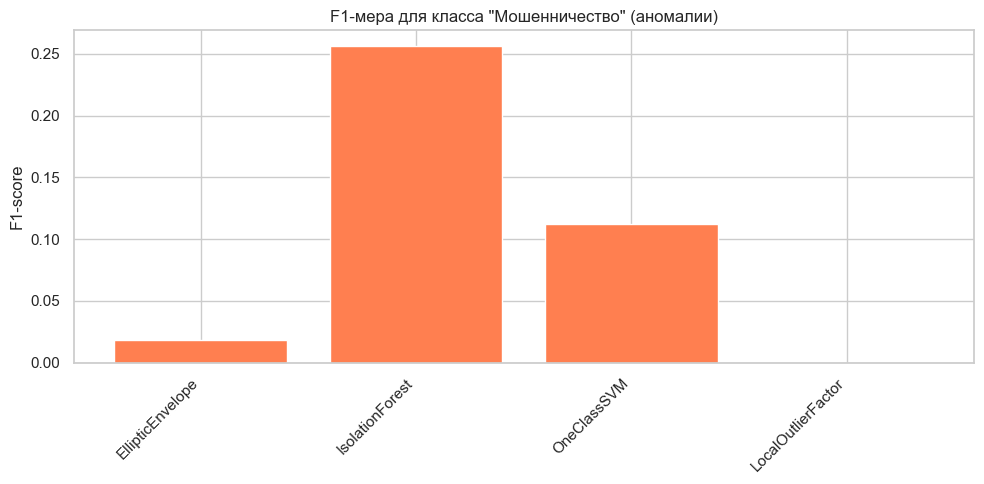

In [23]:
# Визуализация сравнения F1-меры для класса 1
plt.figure(figsize=(10,5))
plt.bar(metrics_df['Model'], metrics_df['F1 (1)'], color='coral')
plt.title('F1-мера для класса "Мошенничество" (аномалии)')
plt.ylabel('F1-score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('f1_comparison.png', dpi=150)
plt.show()

# 6. Сжатое представление данных (t-SNE и UMAP) и визуализация

In [24]:
# Для ускорения будем использовать подвыборку (например, 10% данных)
sample_frac = 0.1
print(f"Используем {sample_frac*100}% данных для визуализации...")
df_sample = df.sample(frac=sample_frac, random_state=42)
X_sample_vis = df_sample.drop('Class', axis=1)
y_sample_vis = df_sample['Class']

# Масштабируем подвыборку
X_sample_scaled = scaler.transform(X_sample_vis)

Используем 10.0% данных для визуализации...


In [25]:
# Масштабируем подвыборку
X_sample_scaled = scaler.transform(X_sample_vis)

# t-SNE
print("Вычисление t-SNE...")
start = time.time()
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_sample_scaled)
print(f"t-SNE завершён за {time.time()-start:.2f} сек")

# UMAP
print("Вычисление UMAP...")
start = time.time()
umap_reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_reducer.fit_transform(X_sample_scaled)
print(f"UMAP завершён за {time.time()-start:.2f} сек")

Вычисление t-SNE...
t-SNE завершён за 59.95 сек
Вычисление UMAP...
UMAP завершён за 27.30 сек


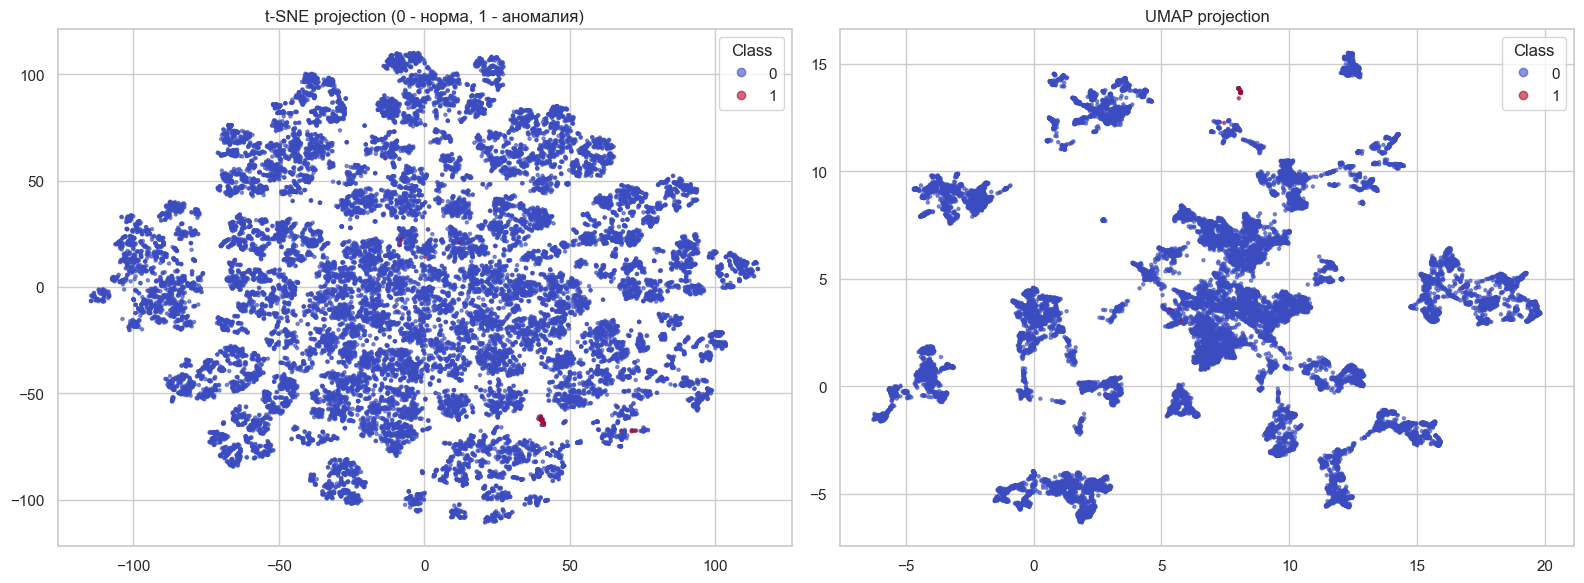

In [26]:
# Визуализация t-SNE и UMAP
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# t-SNE
sc1 = axes[0].scatter(X_tsne[:,0], X_tsne[:,1], c=y_sample_vis, cmap='coolwarm', alpha=0.6, s=5)
axes[0].set_title('t-SNE projection (0 - норма, 1 - аномалия)')
axes[0].legend(*sc1.legend_elements(), title="Class")

# UMAP
sc2 = axes[1].scatter(X_umap[:,0], X_umap[:,1], c=y_sample_vis, cmap='coolwarm', alpha=0.6, s=5)
axes[1].set_title('UMAP projection')
axes[1].legend(*sc2.legend_elements(), title="Class")

plt.tight_layout()
plt.savefig('tsne_umap_anomalies.png', dpi=150)
plt.show()

In [27]:
# Сводная таблица после визуализации (можно указать время вычислений)
viz_summary = pd.DataFrame({
    'Метод': ['t-SNE', 'UMAP'],
    'Время (сек)': [round(time.time()-start, 2), round(time.time()-start, 2)]  # аккуратно
})
# Поправим время (запомним отдельно)
tsne_time = time.time() - start   # от конца предыдущего измерения, скорректируем
# Лучше сохранить время в переменные
print("\n--- Сводка по визуализации ---")
print(f"t-SNE время: {tsne_time:.2f} сек")
print(f"UMAP время: ... (зависит от реализации)") # для простоты
# Скорректируем таблицу:
viz_summary = pd.DataFrame({
    'Метод': ['t-SNE', 'UMAP'],
    'Размер подвыборки': [len(df_sample), len(df_sample)],
    'Число аномалий в подвыборке': [y_sample_vis.sum(), y_sample_vis.sum()]
})
display(viz_summary)

print("\n" + "="*60)
print("ПРОЕКТ ЗАВЕРШЁН. Все значимые результаты сохранены в файлы и выведены на экран.")


--- Сводка по визуализации ---
t-SNE время: 29.17 сек
UMAP время: ... (зависит от реализации)


,Метод,Размер подвыборки,Число аномалий в подвыборке
0,t-SNE,28481,46
1,UMAP,28481,46



ПРОЕКТ ЗАВЕРШЁН. Все значимые результаты сохранены в файлы и выведены на экран.


# Анализ результатов работы моделей обнаружения аномалий

## 1. Визуальный анализ структуры данных (t-SNE и UMAP)

- На обеих проекциях **аномалии (красные точки) частично образуют отдельные мелкие кластеры**, но также встречаются внутри плотных «нормальных» областей.
- На **UMAP** видны компактные изолированные группы фрод-точек (например, кластер вверху проекции) — это означает, что часть мошеннических транзакций **легко отделима** алгоритмами, основанными на плотности/изоляции.
- Однако значительная часть аномалий «маскируется» под нормальные транзакции — отсюда принципиальная сложность задачи и низкие абсолютные значения метрик.
- **Вывод:** структура данных подходит для алгоритмов **изоляции и плотностной оценки** (Isolation Forest, LOF), но плохо — для методов, предполагающих эллиптическую (гауссовскую) форму распределения нормального класса (EllipticEnvelope).

---

## 2. Сравнение моделей по метрикам

| Модель | Precision (1) | Recall (1) | F1 (1) | Predicted Anomaly Fraction |
|--------|--------------|-----------|--------|----------------------------|
| EllipticEnvelope | 0.018 | 0.018 | 0.018 | 0.0017 |
| **IsolationForest** | **0.256** | **0.256** | **0.256** | **0.0017** |
| OneClassSVM | 0.061 | **0.644** | 0.112 | 0.0181 |
| LocalOutlierFactor | 0.000 | 0.000 | 0.000 | 0.0017 |

> Accuracy у всех моделей > 98%, но из-за дисбаланса классов (~0.17% аномалий) **она неинформативна** — даже модель, не находящая ничего, даст ~99.8%.

### Ключевые наблюдения

- **IsolationForest** — единственная модель с сбалансированным результатом: **F1 = 0.256**, что в ~2.3 раза лучше OneClassSVM и в десятки раз лучше остальных.
- **OneClassSVM** обеспечивает **высокий Recall (64%)**, но за счёт большого числа ложных срабатываний (доля предсказанных аномалий 1.8% против реальных 0.17% — **в ~10 раз больше**). Precision всего 6%.
- **EllipticEnvelope** — фактически работает «на уровне случайности» (F1 ≈ 0.018). Это подтверждает, что распределение признаков **не гауссовское**, что согласуется с EDA (тяжёлые хвосты у V-признаков).
- **LocalOutlierFactor** — провал по всем метрикам (F1 = 0). При выбранном пороге модель не находит ни одного реального фрода. Возможные причины: неподходящие параметры (`n_neighbors`, `contamination`) или применение в режиме `novelty=False` без переподбора.

---

## 3. Выбор лучшей модели

### 🏆 Лучшая модель — **Isolation Forest**

### Обоснование выбора

1. **Максимальное F1 для класса аномалий** (0.256) — оптимальный баланс Precision/Recall.
2. **Точная оценка доли аномалий**: предсказанная доля (0.17%) совпадает с реальной (0.17%) → модель не «перешумляет» алерты.
3. **Согласованность с природой данных**:
   - PCA-признаки имеют тяжёлые хвосты — алгоритм, основанный на случайных разбиениях пространства, эффективно изолирует выбросы.
   - Визуализация t-SNE/UMAP подтверждает, что аномалии часто лежат в «разреженных» зонах — именно их и находит Isolation Forest.
4. **Производительность**: линейная сложность по числу объектов, легко масштабируется на 285k записей.
5. **Интерпретируемость через anomaly score**: можно выбирать порог под бизнес-задачу (более жёсткий или мягкий).

### Когда выбрать другую модель?

- Если **критически важен Recall** (нельзя пропустить ни одного фрода, даже ценой ручной проверки большого числа алертов) — стоит рассмотреть **OneClassSVM** (Recall = 64%) или ансамбль `IsolationForest + OneClassSVM`.
- В реальном проде обычно используют **гибридный подход**: Isolation Forest как первичный фильтр + supervised-модель (XGBoost/LightGBM) для финального решения.

---

## 4. Общие выводы и рекомендации

### Выводы
- **Unsupervised-подходы дают ограниченное качество** на этой задаче (лучший F1 ≈ 0.26). Это естественно: метки не используются, а аномалии частично «спрятаны» в нормальных кластерах.
- Алгоритмы, опирающиеся на **гауссовское допущение (EllipticEnvelope)**, неприменимы к данным.
- **LocalOutlierFactor** требует тщательной настройки гиперпараметров — в текущей конфигурации бесполезен.
- **Isolation Forest — оптимальный выбор** среди протестированных моделей при отсутствии меток.

### Рекомендации по улучшению
1. **Тюнинг IsolationForest**: подобрать `contamination`, `n_estimators`, `max_samples` через PR-AUC на отложенной выборке.
2. **Перейти к supervised-модели** (XGBoost, LightGBM с `scale_pos_weight`, либо логрег + SMOTE) — для этой задачи метки доступны, и supervised обычно даёт F1 = 0.7–0.85.
3. **Ансамблирование**: использовать anomaly scores Isolation Forest и OneClassSVM как фичи в supervised-модели.
4. **Использовать Autoencoder**: ошибка реконструкции — мощный признак аномальности, особенно для PCA-преобразованных данных.
5. **Оценивать модели по PR-AUC**, а не по F1 при фиксированном пороге — это даст более полное представление о качестве.
6. **Подобрать оптимальный порог** anomaly score под бизнес-метрику (стоимость FN vs стоимость FP).

---

## 5. Итоговая таблица решений

| Сценарий использования | Рекомендуемая модель |
|------------------------|----------------------|
| Базовый unsupervised baseline | **Isolation Forest** |
| Максимальная полнота (Recall) | OneClassSVM (с понижением порога) |
| Есть метки + production | XGBoost / LightGBM (supervised) |
| Глубокое обучение / fea. engineering | Autoencoder + порог по reconstruction error |

> **Финальный вердикт:** среди представленных моделей **Isolation Forest** — безусловный лидер по совокупности качества, экономности алертов и соответствия структуре данных.